# Decision Tree Classifier 

#### Can **rule-based thresholds** across economic features distinguish Weak and Strong PCE growth better than the linear (SVM) and distance-based (KNN) models?

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from pathlib import Path

In [2]:
DATA_DIR = Path("data")

X_train = pd.read_csv(
    DATA_DIR / "(experiment) X_train.csv",
    index_col=0,
    parse_dates=True
)

y_train = pd.read_csv(
    DATA_DIR / "(experiment) y_train.csv",
    index_col=0,
    parse_dates=True
)

X_test = pd.read_csv(
    DATA_DIR / "(experiment) X_test.csv",
    index_col=0,
    parse_dates=True
)

y_test = pd.read_csv(
    DATA_DIR / "(experiment) y_test.csv",
    index_col=0,
    parse_dates=True
)

In [3]:
print("=" * 50)
print("TRAIN / TEST SPLIT")
print("=" * 50)

print("Training observations:", len(X_train))
print("Testing observations:", len(X_test))

print("\nTraining period:")
print(X_train.index.min(), "to", X_train.index.max())

print("\nTesting period:")
print(X_test.index.min(), "to", X_test.index.max())

print("\nTraining class distribution:")
print(y_train.value_counts().sort_index())

print("\nTesting class distribution:")
print(y_test.value_counts().sort_index())

TRAIN / TEST SPLIT
Training observations: 59
Testing observations: 18

Training period:
2007-06-30 00:00:00 to 2021-12-31 00:00:00

Testing period:
2022-03-31 00:00:00 to 2026-06-30 00:00:00

Training class distribution:
PCE_Regime
0             29
1             30
Name: count, dtype: int64

Testing class distribution:
PCE_Regime
0              8
1             10
Name: count, dtype: int64


In [4]:
## Decision Trees do not require feature scaling, we can simplify the pipeline. 

# ============================================================
# DECISION TREE CLASSIFICATION MODEL
# PCE Growth Regime Classification
# ============================================================

from sklearn.tree import DecisionTreeClassifier
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer

from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report
)

In [5]:
# ============================================================
# 1. BUILD DECISION TREE PIPELINE
# ============================================================

dt_pipeline = Pipeline([
    
    # Fill missing values using training medians
    ("imputer", SimpleImputer(strategy="median")),
    
    # Decision Tree
    ("tree", DecisionTreeClassifier(
        criterion="gini",
        max_depth=3,
        min_samples_leaf=3,
        random_state=42
    ))
])

print(dt_pipeline)

Pipeline(steps=[('imputer', SimpleImputer(strategy='median')),
                ('tree',
                 DecisionTreeClassifier(max_depth=3, min_samples_leaf=3,
                                        random_state=42))])


#### Startign with **small**, **constrained tree**

`max_depth=3` and `min_samples_leaf=3` reduce the risk that the tree simply memorizes the 59 training quarters.

In [6]:
# ============================================================
# 2. TRAIN DECISION TREE
# ============================================================

dt_pipeline.fit(
    X_train,
    y_train
)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('imputer', ...), ('tree', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"missing_values missing_values: int, float, str, np.nan, None or pandas.NA, default=np.nanThe placeholder for the missing values. All occurrences of`missing_values` will be imputed. For pandas' dataframes withnullable integer dtypes with missing values, `missing_values`can be set to either `np.nan` or `pd.NA`.",nan
,"strategy strategy: str or Callable, default='mean'The imputation strategy.- If ""mean"", then replace missing values using the mean along each column. Can only be used with numeric data.- If ""median"", then replace missing values using the median along each column. Can only be used with numeric data.- If ""most_frequent"", then replace missing using the most frequent value along each column. Can be used with strings or numeric data. If there is more than one such value, only the smallest is returned.- If ""constant"", then replace missing values with fill_value. Can be used with strings or numeric data.- If an instance of Callable, then replace missing values using the scalar statistic returned by running the callable over a dense 1d array containing non-missing values of each column... versionadded:: 0.20 strategy=""constant"" for fixed value imputation... versionadded:: 1.5 strategy=callable for custom value imputation.",'median'
,"fill_value fill_value: str or numerical value, default=NoneWhen strategy == ""constant"", `fill_value` is used to replace alloccurrences of missing_values. For string or object data types,`fill_value` must be a string.If `None`, `fill_value` will be 0 when imputing numericaldata and ""missing_value"" for strings or object data types.",None
,"copy copy: bool, default=TrueIf True, a copy of X will be created. If False, imputation willbe done in-place whenever possible. Note that, in the following cases,a new copy will always be made, even if `copy=False`:- If `X` is not an array of floating values;- If `X` is encoded as a CSR matrix;- If `add_indicator=True`.",True
,"add_indicator add_indicator: bool, default=FalseIf True, a :class:`MissingIndicator` transform will stack onto outputof the imputer's transform. This allows a predictive estimatorto account for missingness despite imputation. If a fea

In [7]:
# ============================================================
# 3. TEST PREDICTIONS
# ============================================================

dt_pred = dt_pipeline.predict(X_test)

dt_prob = dt_pipeline.predict_proba(X_test)[:, 1]


dt_predictions = pd.DataFrame({
    "Actual": y_test.squeeze(),
    "Predicted": dt_pred,
    "Probability_Strong": dt_prob
})

display(dt_predictions)

,Actual,Predicted,Probability_Strong
Quarter,,,
2022-03-31,0,1,1.000000
2022-06-30,1,1,1.000000
2022-09-30,0,1,0.518519
2022-12-31,0,1,0.518519
2023-03-31,1,1,0.518519
2023-06-30,0,1,0.518519
2023-09-30,1,1,0.518519
2023-12-31,1,1,0.518519
2024-03-31,0,1,0.518519


In [8]:
# ============================================================
# 4. DECISION TREE PERFORMANCE METRICS
# ============================================================

dt_accuracy = accuracy_score(
    y_test,
    dt_pred
)

dt_balanced_accuracy = balanced_accuracy_score(
    y_test,
    dt_pred
)

dt_precision = precision_score(
    y_test,
    dt_pred,
    zero_division=0
)

dt_recall = recall_score(
    y_test,
    dt_pred,
    zero_division=0
)

dt_f1 = f1_score(
    y_test,
    dt_pred,
    zero_division=0
)

dt_roc_auc = roc_auc_score(
    y_test,
    dt_prob
)


print("=" * 55)
print("DECISION TREE MODEL PERFORMANCE")
print("=" * 55)

print(f"Accuracy:           {dt_accuracy:.4f}")
print(f"Balanced Accuracy:  {dt_balanced_accuracy:.4f}")
print(f"Precision:          {dt_precision:.4f}")
print(f"Recall:             {dt_recall:.4f}")
print(f"F1 Score:           {dt_f1:.4f}")
print(f"ROC-AUC:            {dt_roc_auc:.4f}")

DECISION TREE MODEL PERFORMANCE
Accuracy:           0.5556
Balanced Accuracy:  0.5000
Precision:          0.5556
Recall:             1.0000
F1 Score:           0.7143
ROC-AUC:            0.4875


In [9]:
# ============================================================
# 5. CLASSIFICATION REPORT
# ============================================================

print(
    classification_report(
        y_test,
        dt_pred,
        target_names=[
            "Weak Growth",
            "Strong Growth"
        ],
        zero_division=0
    )
)

               precision    recall  f1-score   support

  Weak Growth       0.00      0.00      0.00         8
Strong Growth       0.56      1.00      0.71        10

     accuracy                           0.56        18
    macro avg       0.28      0.50      0.36        18
 weighted avg       0.31      0.56      0.40        18



In [10]:
# ============================================================
# 6. CONFUSION MATRIX
# ============================================================

dt_cm = confusion_matrix(
    y_test,
    dt_pred
)

print("Decision Tree Confusion Matrix:")
print(dt_cm)

Decision Tree Confusion Matrix:
[[ 0  8]
 [ 0 10]]


$$
\begin{bmatrix}
TN=0 & FP=8 \\
FN=0 & TP=10
\end{bmatrix}
$$

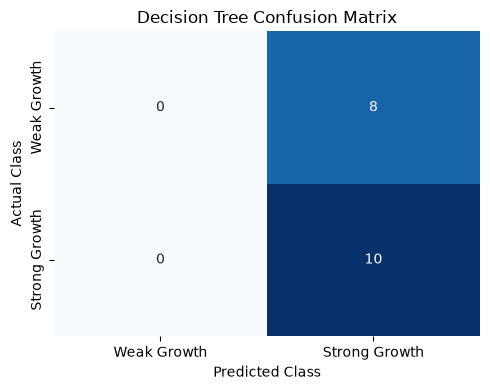

In [11]:
# ============================================================
# 7. CONFUSION MATRIX VISUALIZATION
# ============================================================

plt.figure(figsize=(5, 4))

sns.heatmap(
    dt_cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    cbar=False,
    xticklabels=[
        "Weak Growth",
        "Strong Growth"
    ],
    yticklabels=[
        "Weak Growth",
        "Strong Growth"
    ]
)

plt.xlabel("Predicted Class")
plt.ylabel("Actual Class")

plt.title(
    "Decision Tree Confusion Matrix"
)

plt.tight_layout()
plt.show()

In [12]:
# ============================================================
# 8. DECISION TREE RESULTS
# ============================================================

dt_results = pd.DataFrame({
    "Model": ["Decision Tree"],
    "Accuracy": [dt_accuracy],
    "Balanced Accuracy": [dt_balanced_accuracy],
    "Precision": [dt_precision],
    "Recall": [dt_recall],
    "F1": [dt_f1],
    "ROC-AUC": [dt_roc_auc]
})

display(dt_results.round(4))

,Model,Accuracy,Balanced Accuracy,Precision,Recall,F1,ROC-AUC
0,Decision Tree,0.5556,0.5,0.5556,1.0,0.7143,0.4875


### Decision Tree V1

| Metric            | **Decision Tree V1** | Interpretation                                               |
| ----------------- | -------------------: | ------------------------------------------------------------ |
| Accuracy          |           **0.5556** | 55.56% of test quarters were classified correctly            |
| Balanced Accuracy |           **0.5000** | Average performance across Weak and Strong classes was 50.0% |
| Precision         |           **0.5556** | When predicting Strong Growth, 55.56% were actually Strong   |
| Recall            |           **1.0000** | It identified 100% of the actual Strong-Growth quarters      |
| F1                |           **0.7143** | High F1 resulted from perfect Strong-Growth recall           |
| ROC-AUC           |           **0.4875** | Probability ranking was slightly worse than random           |


### interpretation: 

Like KNN, Decision Tree V1 predicted all 18 observations as Strong Growth. Therefore, its apparently high F1 score does not represent balanced classification ability.

### One major advantage of Decision Trees is that they can show which variables were actually used to split the data

In [13]:
# ============================================================
# 9. DECISION TREE FEATURE IMPORTANCE
# ============================================================

fitted_tree = dt_pipeline.named_steps["tree"]

dt_importance = pd.DataFrame({
    "Feature": X_train.columns,
    "Importance": fitted_tree.feature_importances_
})

dt_importance = (
    dt_importance[
        dt_importance["Importance"] > 0
    ]
    .sort_values(
        "Importance",
        ascending=False
    )
    .reset_index(drop=True)
)

display(dt_importance)

,Feature,Importance
0,Federal Funds Rate,0.474423
1,Exchange Rate,0.374166
2,Interest Income,0.151411


### This tells us which economic predictors contributed to the tree's splitting decisions.

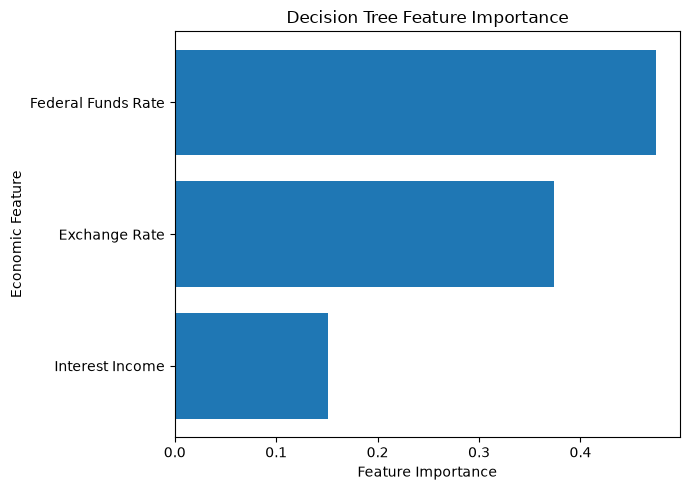

In [14]:
# ============================================================
# 10. VISUALIZE TREE FEATURE IMPORTANCE
# ============================================================

top_dt_features = dt_importance.head(15)

plt.figure(figsize=(7, 5))

plt.barh(
    top_dt_features["Feature"][::-1],
    top_dt_features["Importance"][::-1]
)

plt.xlabel("Feature Importance")
plt.ylabel("Economic Feature")

plt.title(
    "Decision Tree Feature Importance"
)

plt.tight_layout()
plt.show()

### Optional: visualize the **actual decision tree**

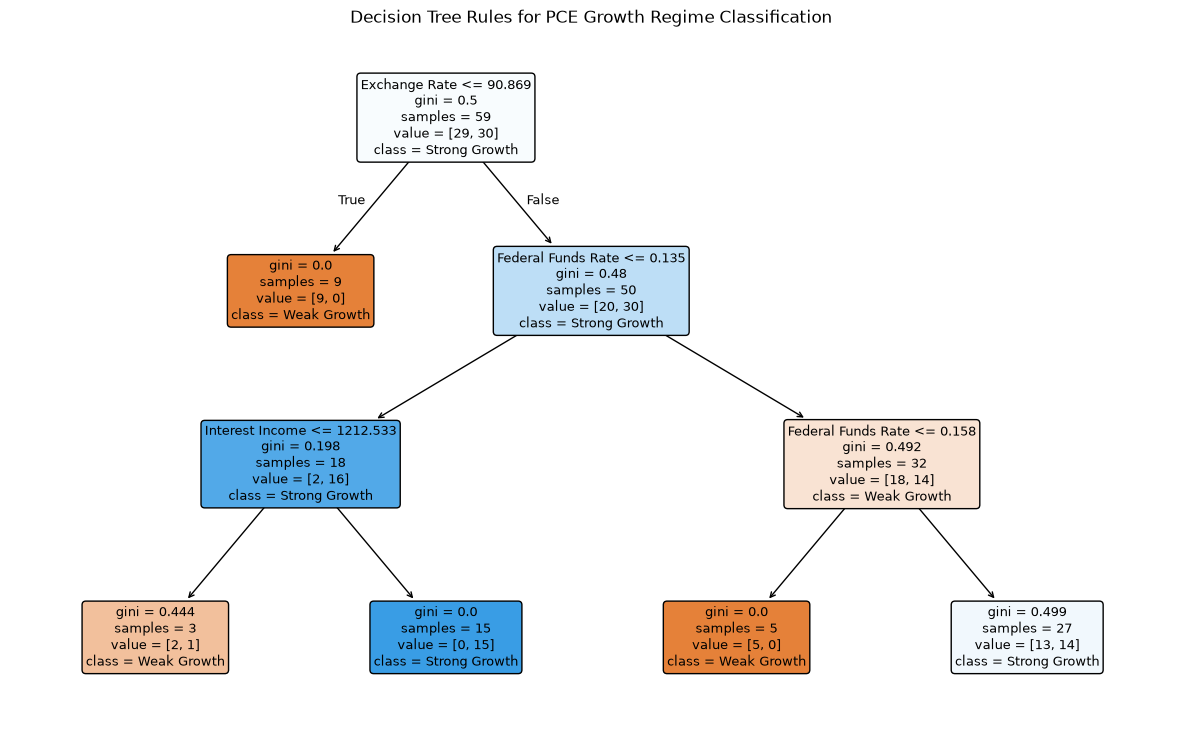

In [15]:
from sklearn.tree import plot_tree

plt.figure(figsize=(15, 9))

plot_tree(
    fitted_tree,
    feature_names=X_train.columns,
    class_names=[
        "Weak Growth",
        "Strong Growth"
    ],
    filled=True,
    rounded=True,
    fontsize=9
)

plt.title(
    "Decision Tree Rules for PCE Growth Regime Classification"
)

plt.show()

### Conclusion: 

The Decision Tree learned meaningful-looking rules in the training period, but those rules failed to generalize to the 2022–2026 test period.

## Evaluate the Decision Tree Performance  --- how to improve this model

### A. Diagnose train vs test performance

In [16]:
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    f1_score,
    roc_auc_score
)

dt_train_pred = dt_pipeline.predict(X_train)
dt_test_pred = dt_pipeline.predict(X_test)

print("TRAIN")
print("Accuracy:",
      accuracy_score(y_train.squeeze(), dt_train_pred))
print("Balanced Accuracy:",
      balanced_accuracy_score(y_train.squeeze(), dt_train_pred))

print("\nTEST")
print("Accuracy:",
      accuracy_score(y_test.squeeze(), dt_test_pred))
print("Balanced Accuracy:",
      balanced_accuracy_score(y_test.squeeze(), dt_test_pred))

TRAIN
Accuracy: 0.7627118644067796
Balanced Accuracy: 0.7591954022988505

TEST
Accuracy: 0.5555555555555556
Balanced Accuracy: 0.5


#### this's strong evidence of poor generalization.  75% vs 50%

Decision Tree Interpretation: 

The Decision Tree achieved 55.56% test accuracy but only 50% balanced accuracy. Although recall for the Strong Growth class reached 100%, the confusion matrix revealed that the model classified all 18 test observations as Strong Growth, **failing to identify any Weak Growth quarters**. 

Therefore, the high Strong Growth recall and F1 score should not be interpreted as evidence of strong classification performance. The tree relied primarily on the Federal Funds Rate, Exchange Rate, and Interest Income; however, their impurity-based feature importance reflects their usefulness for historical training splits rather than stable predictive or causal economic relationships. 

The deterioration in out-of-sample performance suggests that the learned thresholds may not generalize to the post-2022 economic regime. 

Further analysis should therefore emphasize time-aware pruning, walk-forward validation, and economically meaningful transformations before evaluating the final Decision Tree model.

## B. prune the Decision Tree

- select parameters using **time-series cross-validation**

In [17]:
from sklearn.model_selection import TimeSeriesSplit, GridSearchCV
from sklearn.tree import DecisionTreeClassifier

tscv = TimeSeriesSplit(n_splits=5)

param_grid = {
    "max_depth": [1, 2, 3, 4],
    "min_samples_split": [5, 10, 15],
    "min_samples_leaf": [3, 5, 8, 10],
    "ccp_alpha": [0.0, 0.001, 0.01, 0.05, 0.1]
}

dt = DecisionTreeClassifier(
    random_state=42
)

grid = GridSearchCV(
    estimator=dt,
    param_grid=param_grid,
    scoring="balanced_accuracy",
    cv=tscv,
    n_jobs=-1
)

grid.fit(X_train, y_train.squeeze())

print("Best parameters:")
print(grid.best_params_)

print("\nBest CV Balanced Accuracy:")
print(grid.best_score_)

Best parameters:
{'ccp_alpha': 0.0, 'max_depth': 2, 'min_samples_leaf': 8, 'min_samples_split': 5}

Best CV Balanced Accuracy:
0.5857142857142857


- 58.57%−50%= 8.57 percentage points---> as modest evidence of predictive signal, not strong performance.

Explaination: 
- `ccp_alpha` : cost-complexity pruning.

In [18]:
best_dt = grid.best_estimator_

print(best_dt)

DecisionTreeClassifier(max_depth=2, min_samples_leaf=8, min_samples_split=5,
                       random_state=42)


In [19]:
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report
)

# Predictions
dt_v2_pred = best_dt.predict(X_test)
dt_v2_prob = best_dt.predict_proba(X_test)[:, 1]

y_test_1d = y_test.squeeze()

# Metrics
print("Decision Tree V2 — Test Performance")
print("------------------------------------")
print("Accuracy:",
      accuracy_score(y_test_1d, dt_v2_pred))

print("Balanced Accuracy:",
      balanced_accuracy_score(y_test_1d, dt_v2_pred))

print("Precision:",
      precision_score(y_test_1d, dt_v2_pred, zero_division=0))

print("Recall:",
      recall_score(y_test_1d, dt_v2_pred, zero_division=0))

print("F1:",
      f1_score(y_test_1d, dt_v2_pred, zero_division=0))

print("ROC-AUC:",
      roc_auc_score(y_test_1d, dt_v2_prob))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test_1d, dt_v2_pred))

print("\nClassification Report:")
print(classification_report(
    y_test_1d,
    dt_v2_pred,
    target_names=["Weak Growth", "Strong Growth"],
    zero_division=0
))

Decision Tree V2 — Test Performance
------------------------------------
Accuracy: 0.4444444444444444
Balanced Accuracy: 0.4875
Precision: 0.5
Recall: 0.1
F1: 0.16666666666666666
ROC-AUC: 0.48750000000000004

Confusion Matrix:
[[7 1]
 [9 1]]

Classification Report:
               precision    recall  f1-score   support

  Weak Growth       0.44      0.88      0.58         8
Strong Growth       0.50      0.10      0.17        10

     accuracy                           0.44        18
    macro avg       0.47      0.49      0.38        18
 weighted avg       0.47      0.44      0.35        18



### Decision Tree V2

| Metric            | **Decision Tree V2** | Interpretation                                                |
| ----------------- | -------------------: | ------------------------------------------------------------- |
| Accuracy          |           **0.4444** | 44.44% of test quarters were classified correctly             |
| Balanced Accuracy |           **0.4875** | Average performance across Weak and Strong classes was 48.75% |
| Precision         |           **0.5000** | When predicting Strong Growth, 50% were actually Strong       |
| Recall            |           **0.1000** | It identified only 10% of the actual Strong-Growth quarters   |
| F1                |           **0.1667** | Very weak balance between precision and recall                |
| ROC-AUC           |           **0.4875** | Probability ranking was slightly worse than random            |


### Interpretation: 

V2 reduced the strong-class prediction tendency of V1, but at the cost of missing most actual Strong-Growth quarters.

### Result: 

- Decision Tree V2 corrected the original bias, but **overcorrected** in the opposite direction.

- The original tree predicted almost everything as Strong Growth. The pruned V2 predicts almost everything as **Weak Growth**.

- pruning did not solve the fundamental problem

- We now have evidence that the problem is probably not simply Decision Tree complexity.

- Hypothesis 1 — Original tree is too complex / overfitted.\
We constrained it heavily using time-aware CV.\
Result: Future performance did not improve.

- Hypothesis 2 — Strong-class prediction is caused by the original tree structure.\
Pruning removed that behavior.\
Result: Yes—but the model simply shifted toward predicting Weak instead.

- the deeper issue appears to be:\
  **unstable `feature-target` relationships across time**
  

## one final Decision Tree diagnostic: **walk-forward stability analysis**.

- try to reduce noise to make model more stable insead of finding many hyperparameters.

In [20]:
from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import balanced_accuracy_score
import pandas as pd
import numpy as np

tscv = TimeSeriesSplit(n_splits=5)

fold_results = []

for fold, (train_idx, val_idx) in enumerate(tscv.split(X_train), start=1):

    X_tr = X_train.iloc[train_idx]
    X_val = X_train.iloc[val_idx]

    y_tr = y_train.squeeze().iloc[train_idx]
    y_val = y_train.squeeze().iloc[val_idx]

    model = best_dt

    model.fit(X_tr, y_tr)

    pred = model.predict(X_val)

    ba = balanced_accuracy_score(y_val, pred)

    fold_results.append({
        "Fold": fold,
        "Train_Start": X_tr.index.min(),
        "Train_End": X_tr.index.max(),
        "Validation_Start": X_val.index.min(),
        "Validation_End": X_val.index.max(),
        "Balanced_Accuracy": ba,
        "Predicted_Weak": np.sum(pred == 0),
        "Predicted_Strong": np.sum(pred == 1)
    })

fold_results = pd.DataFrame(fold_results)

display(fold_results)

,Fold,Train_Start,Train_End,Validation_Start,Validation_End,Balanced_Accuracy,Predicted_Weak,Predicted_Strong
0,1,2007-06-30,2010-09-30,2010-12-31,2012-12-31,0.500000,9,0
1,2,2007-06-30,2012-12-31,2013-03-31,2015-03-31,0.500000,9,0
2,3,2007-06-30,2015-03-31,2015-06-30,2017-06-30,0.500000,0,9
3,4,2007-06-30,2017-06-30,2017-09-30,2019-09-30,0.500000,9,0
4,5,2007-06-30,2019-09-30,2019-12-31,2021-12-31,0.928571,3,6


| Fold       | Validation Period | Balanced Accuracy | Weak Predictions | Strong Predictions | Behavior             |
| ---------- | ----------------- | ----------------: | ---------------: | -----------------: | -------------------- |
| 1          | 2010 Q4–2012 Q4   |             0.500 |                9 |                  0 | All Weak             |
| 2          | 2013 Q1–2015 Q1   |             0.500 |                9 |                  0 | All Weak             |
| 3          | 2015 Q2–2017 Q2   |             0.500 |                0 |                  9 | All Strong           |
| 4          | 2017 Q3–2019 Q3   |             0.500 |                9 |                  0 | All Weak             |
| 5          | 2019 Q4–2021 Q4   |         **0.929** |                3 |                  6 | Excellent separation |
| Final Test | 2022 Q1–2026 Q2   |         **0.488** |               16 |                  2 | Mostly Weak          |


## Observation: 

- The main issue is not a gradual deterioration over time. It is **extreme instability across time periods**
- The Decision Tree is not actually classifying economic regimes. It is collapsing into predicting a single regime.
- In the result of Decision Tree, the diagnosis is:\
  **Small sample + unstable temporal relationships + tree threshold sensitivity**

## [Reference]

| Fold               | Period                      | U.S. President(s)             | Monetary-policy environment                                                                                                           | Major fiscal-policy environment                                                                                                        | Economic regime / interpretation                                           |
| ------------------ | --------------------------- | ----------------------------- | ------------------------------------------------------------------------------------------------------------------------------------- | -------------------------------------------------------------------------------------------------------------------------------------- | -------------------------------------------------------------------------- |
| **1 – Train**      | **2007-06-30 → 2010-09-30** | George W. Bush → Barack Obama | **Extreme easing:** Fed funds rate fell from 5.25% in 2007 to **0–0.25% by Dec. 2008**; emergency liquidity programs; beginning of QE | 2008 Economic Stimulus Act; TARP/financial stabilization; **ARRA 2009** stimulus                                                       | **Global Financial Crisis → Great Recession → early recovery**             |
| **1 – Validation** | **2010-12-31 → 2012-12-31** | Barack Obama                  | **Near-zero rates + QE:** QE2; Operation Twist; strong forward guidance                                                               | Continued ARRA effects; temporary payroll-tax reduction; unemployment support; **Budget Control Act 2011** introduces fiscal restraint | **Post-crisis recovery**, weak growth and deleveraging                     |
| **2 – Train**      | **2007-06-30 → 2012-12-31** | Bush → Obama                  | Covers conventional easing → zero lower bound → QE/Operation Twist                                                                    | Crisis stimulus → ARRA → later deficit-control measures                                                                                | Model learns the **entire financial-crisis and early-recovery transition** |
| **2 – Validation** | **2013-03-31 → 2015-03-31** | Barack Obama                  | Rates remain near zero; **QE3**, followed by tapering; asset purchases end in 2014                                                    | More restrained federal fiscal stance; sequestration/Budget Control Act environment; American Taxpayer Relief Act effects              | **Stable expansion / normalization begins**                                |
| **3 – Train**      | **2007-06-30 → 2015-03-31** | Bush → Obama                  | Crisis easing + QE + beginning of monetary normalization                                                                              | Crisis stimulus → fiscal consolidation                                                                                                 | Increasingly diverse training set: **recession + recovery + expansion**    |
| **3 – Validation** | **2015-06-30 → 2017-06-30** | Barack Obama → Donald Trump   | **Monetary tightening begins:** first rate hike Dec. 2015; gradual rate increases in 2016–17                                          | Relatively neutral/restrained fiscal policy initially; transition to Trump fiscal agenda in 2017                                       | **Late-cycle expansion + beginning of Fed normalization**                  |
| **4 – Train**      | **2007-06-30 → 2017-06-30** | Bush → Obama → Trump          | Full cycle from crisis easing to early tightening                                                                                     | Crisis stimulus → consolidation → transition toward tax-cut policy                                                                     | Training now includes several very different policy regimes                |
| **4 – Validation** | **2017-09-30 → 2019-09-30** | Donald Trump                  | **Tightening → easing:** rate increases through 2018; balance-sheet normalization; Fed starts cutting rates in 2019                   | **Tax Cuts and Jobs Act (2017)**; higher federal spending under subsequent budget agreements                                           | **Mature expansion → slowdown / pre-COVID easing**                         |
| **5 – Train**      | **2007-06-30 → 2019-09-30** | Bush → Obama → Trump          | Crisis easing → QE → normalization → tightening → 2019 easing                                                                         | Multiple fiscal regimes including ARRA, austerity/consolidation, and TCJA                                                              | Very broad **pre-pandemic economic history**                               |
| **5 – Validation** | **2019-12-31 → 2021-12-31** | Donald Trump → Joe Biden      | **Emergency easing:** Fed cuts rates to **0–0.25% in March 2020**, massive asset purchases and emergency credit facilities            | **CARES Act 2020** + additional pandemic relief → **American Rescue Plan 2021**                                                        | **COVID shock → extraordinary stimulus → rapid reopening/recovery**        |


## [Simpler reading]

| Approx. period | Regime label                        | Monetary policy                | Fiscal policy                               | PCE relevance                                              |
| -------------- | ----------------------------------- | ------------------------------ | ------------------------------------------- | ---------------------------------------------------------- |
| **2007–2009**  | **Financial Crisis / Recession**    | Rapid easing → zero rates + QE | Strong emergency stimulus                   | Consumption contraction, credit stress, unemployment shock |
| **2010–2014**  | **Post-Crisis Recovery**            | Zero rates + QE                | Stimulus fading → fiscal restraint          | Slow household recovery, deleveraging                      |
| **2015–2017**  | **Normalization / Expansion**       | Gradual rate increases         | Relatively moderate → tax-policy transition | Stronger labor market and consumption                      |
| **2018–2019**  | **Late Expansion**                  | Tightening → 2019 easing       | TCJA / expansionary fiscal influence        | Strong consumption but slowing macro conditions            |
| **2020–2021**  | **COVID Shock / Stimulus Recovery** | Zero rates + massive QE        | Extraordinary fiscal stimulus               | **Extremely abnormal PCE behavior**                        |


## important message: 
whether relationships learned under **one economic environment generalize** to a **new policy/economic regime**.

# Back to validate the 3 feature importance with the 5 folds  

In [23]:
display(dt_importance)

,Feature,Importance
0,Federal Funds Rate,0.474423
1,Exchange Rate,0.374166
2,Interest Income,0.151411


## measure **feature-importance stability across folds**.

In [24]:
import pandas as pd
import numpy as np
from sklearn.model_selection import TimeSeriesSplit
from sklearn.tree import DecisionTreeClassifier

tscv = TimeSeriesSplit(n_splits=5)

importance_results = []

for fold, (train_idx, val_idx) in enumerate(tscv.split(X_train), start=1):

    X_tr = X_train.iloc[train_idx]
    y_tr = y_train.squeeze().iloc[train_idx]

    model = DecisionTreeClassifier(
        **grid.best_params_,
        random_state=42
    )

    model.fit(X_tr, y_tr)

    fold_importance = pd.DataFrame({
        "Feature": X_train.columns,
        "Importance": model.feature_importances_
    })

    fold_importance = (
        fold_importance
        .query("Importance > 0")
        .sort_values("Importance", ascending=False)
    )

    fold_importance["Fold"] = fold

    importance_results.append(fold_importance)

importance_stability = pd.concat(
    importance_results,
    ignore_index=True
)

display(
    importance_stability[
        ["Fold", "Feature", "Importance"]
    ]
)

,Fold,Feature,Importance
0,2,Exchange Rate,1.000000
1,3,Exchange Rate,0.533962
2,3,Personal Savings,0.466038
3,4,Exchange Rate,0.521211
4,4,Employment Rate,0.478789
5,5,Exchange Rate,0.648559
6,5,Federal Funds Rate,0.351441


In [25]:
feature_stability = (
    importance_stability
    .groupby("Feature")
    .agg(
        Folds_Selected=("Fold", "nunique"),
        Mean_Importance=("Importance", "mean"),
        Max_Importance=("Importance", "max")
    )
    .sort_values(
        ["Folds_Selected", "Mean_Importance"],
        ascending=False
    )
)

display(feature_stability)

,Folds_Selected,Mean_Importance,Max_Importance
Feature,,,
Exchange Rate,4,0.675933,1.000000
Employment Rate,1,0.478789,0.478789
Personal Savings,1,0.466038,0.466038
Federal Funds Rate,1,0.351441,0.351441


## Visulization 

## 1. Feature Importance Across Time-Series Folds

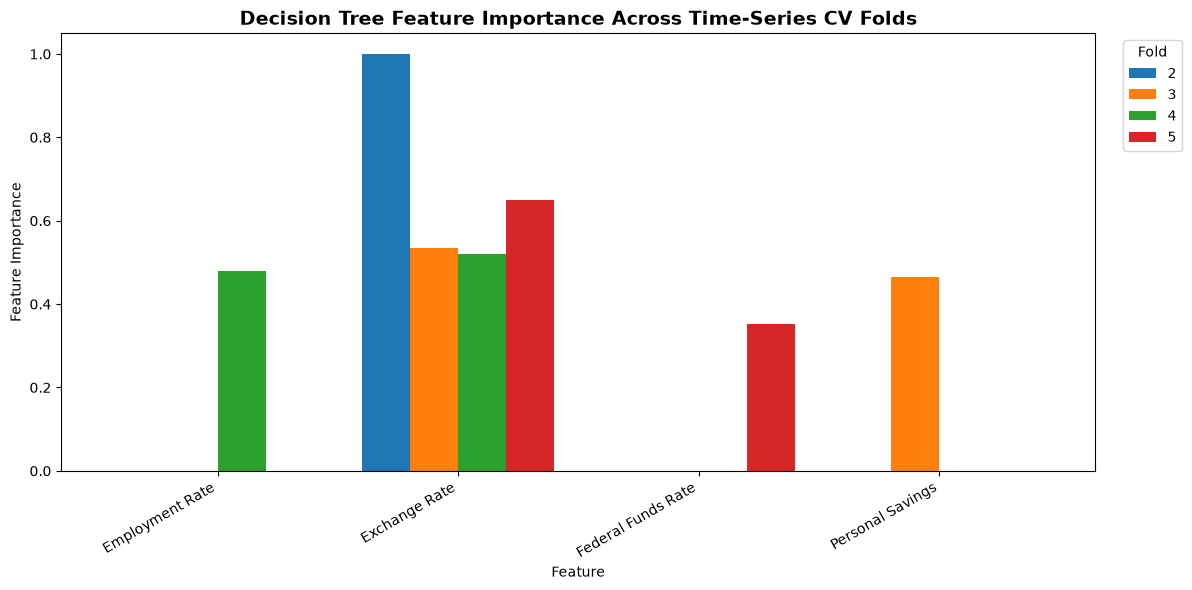

In [26]:
import matplotlib.pyplot as plt
import pandas as pd

# ------------------------------------------------------------
# Prepare data
# ------------------------------------------------------------

plot_data = importance_stability.pivot(
    index="Feature",
    columns="Fold",
    values="Importance"
).fillna(0)

# ------------------------------------------------------------
# Plot
# ------------------------------------------------------------

ax = plot_data.plot(
    kind="bar",
    figsize=(12, 6),
    width=0.8
)

ax.set_title(
    "Decision Tree Feature Importance Across Time-Series CV Folds",
    fontsize=14,
    fontweight="bold"
)

ax.set_xlabel("Feature")
ax.set_ylabel("Feature Importance")

ax.legend(
    title="Fold",
    bbox_to_anchor=(1.02, 1),
    loc="upper left"
)

plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()

## 2. Feature Selection Stability

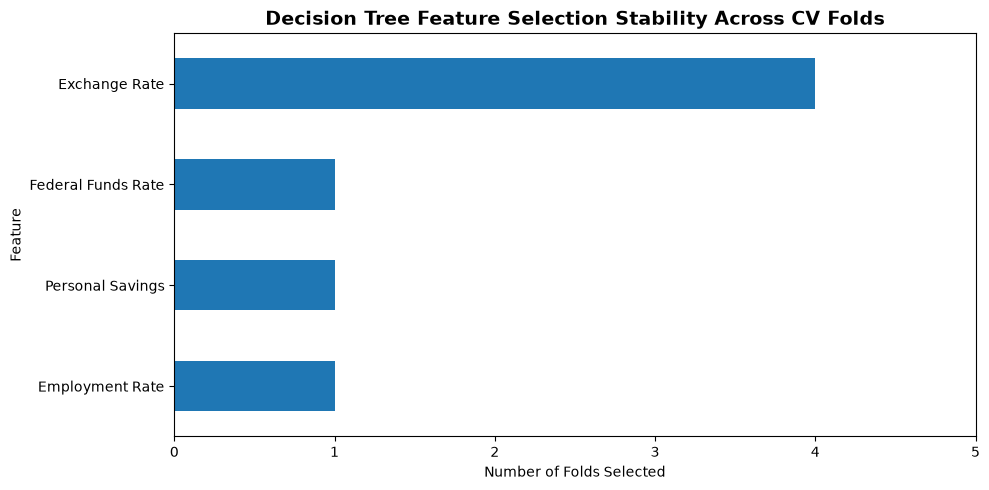

In [27]:
# Sort by number of folds selected
stability_plot = (
    feature_stability
    .sort_values("Folds_Selected", ascending=True)
)

ax = stability_plot["Folds_Selected"].plot(
    kind="barh",
    figsize=(10, 5)
)

ax.set_title(
    "Decision Tree Feature Selection Stability Across CV Folds",
    fontsize=14,
    fontweight="bold"
)

ax.set_xlabel("Number of Folds Selected")
ax.set_ylabel("Feature")

# There are 5 CV folds
ax.set_xlim(0, 5)

plt.tight_layout()
plt.show()

### Interpretation: 

**Exchange Rate** is the only feature showing substantial selection stability across the time-series folds

## 3. Mean Importance + Selection Frequency

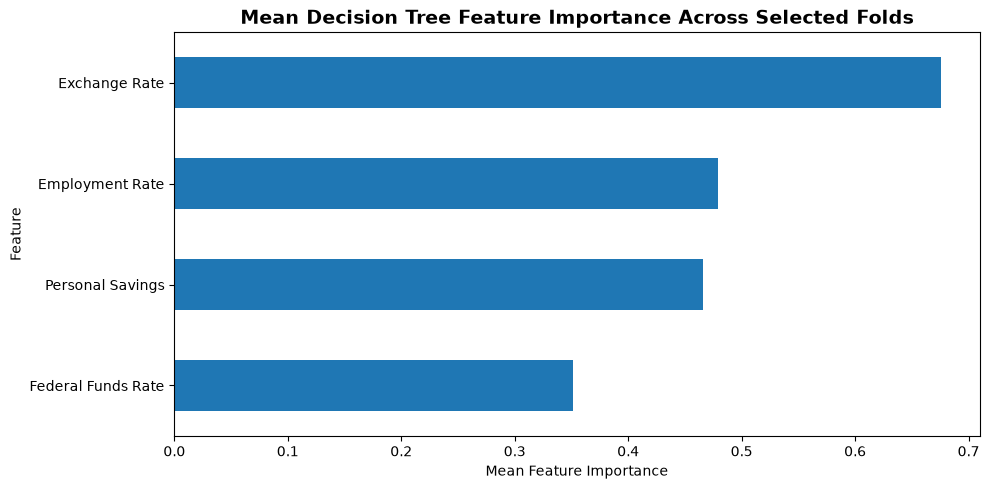

In [28]:
mean_importance = (
    feature_stability
    .sort_values("Mean_Importance", ascending=True)
)

ax = mean_importance["Mean_Importance"].plot(
    kind="barh",
    figsize=(10, 5)
)

ax.set_title(
    "Mean Decision Tree Feature Importance Across Selected Folds",
    fontsize=14,
    fontweight="bold"
)

ax.set_xlabel("Mean Feature Importance")
ax.set_ylabel("Feature")

plt.tight_layout()
plt.show()

## 4. Add Overall Mean Importance

In [29]:
N_FOLDS = 5

feature_stability["Overall_Mean_Importance"] = (
    feature_stability["Mean_Importance"]
    * feature_stability["Folds_Selected"]
    / N_FOLDS
)

feature_stability["Selection_Rate"] = (
    feature_stability["Folds_Selected"]
    / N_FOLDS
)

display(feature_stability)

,Folds_Selected,Mean_Importance,Max_Importance,Overall_Mean_Importance,Selection_Rate
Feature,,,,,
Exchange Rate,4,0.675933,1.000000,0.540746,0.8
Employment Rate,1,0.478789,0.478789,0.095758,0.2
Personal Savings,1,0.466038,0.466038,0.093208,0.2
Federal Funds Rate,1,0.351441,0.351441,0.070288,0.2


### Using Selection rate

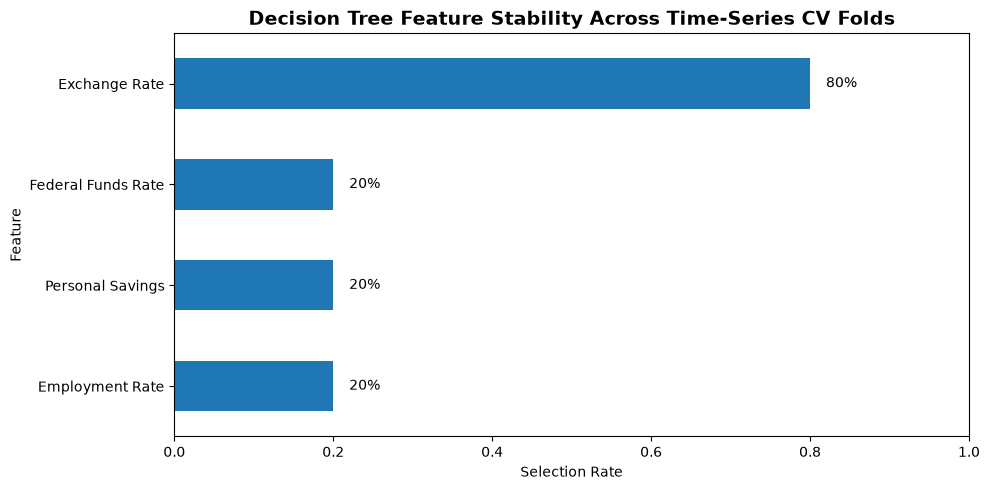

In [30]:
selection_plot = (
    feature_stability
    .sort_values("Selection_Rate", ascending=True)
)

ax = selection_plot["Selection_Rate"].plot(
    kind="barh",
    figsize=(10, 5)
)

ax.set_title(
    "Decision Tree Feature Stability Across Time-Series CV Folds",
    fontsize=14,
    fontweight="bold"
)

ax.set_xlabel("Selection Rate")
ax.set_ylabel("Feature")

ax.set_xlim(0, 1)

# Show percentages beside bars
for i, value in enumerate(selection_plot["Selection_Rate"]):
    ax.text(
        value + 0.02,
        i,
        f"{value:.0%}",
        va="center"
    )

plt.tight_layout()
plt.show()

#### Feature Stability Interpretation: 

The **Exchange Rate** was selected by the Decision Tree in **four of five time-series cross-validation folds (80%)**, making it the most consistently selected feature. Employment Rate, Personal Savings, and Federal Funds Rate appeared in only one fold each (20%). However, selection stability should not be interpreted as evidence of strong predictive power: four of the five validation folds achieved only 0.50 balanced accuracy. 

Therefore, **the Exchange Rate appears to provide a recurring historical splitting rule, but its ability to distinguish Weak and Strong PCE growth regimes remains limited out of sample**.